# Makemore Part 1 — Bigram Language Model

This notebook builds a **bigram character-level language model** that learns to generate human-like names by studying patterns in a large list of real names.

We implement the model in **two ways** and compare them:

| Approach | Method | Key idea |
|---|---|---|
| **Statistical** | Count matrix + smoothing | Directly count how often each pair of characters appears |
| **Neural Network** | Single linear layer + softmax | Learn the same distribution via gradient descent |

Both approaches ultimately optimise the same objective — **minimising the average negative log-likelihood** of the training data — and produce equivalent results.

**Topics covered:**
- Character tokenisation and bigram extraction
- Probability estimation with Laplace (add-1) smoothing
- One-hot encoding and the softmax function
- Forward / backward pass and gradient descent
- L2 regularisation
- Autoregressive sampling

## 1  Imports

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

%matplotlib inline

## MLflow Setup

We use **MLflow** to track all experiments — hyperparameters, loss curves, and model weights — so results are reproducible and comparable across runs.

In [4]:
# Install if needed:
!pip install mlflow

import mlflow
import mlflow.pytorch

# Use a local tracking URI so no server is needed
mlflow.set_tracking_uri("mlruns")
mlflow.set_experiment("makemore-part1-bigram")

print(f"MLflow tracking URI : {mlflow.get_tracking_uri()}")
print(f"Active experiment   : makemore-part1-bigram")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.2/866.2 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207

/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/24 14:27:04 INFO mlflow.tracking.fluent: Experiment with name 'makemore-part1-bigram' does not exist. Creating a new experiment.


MLflow tracking URI : mlruns
Active experiment   : makemore-part1-bigram


## 2  Load and Explore the Dataset

`names.txt` contains one name per line (e.g. *emma*, *olivia*, …).  
We read every line into a Python list so that each element is a single lowercase name string.

In [5]:
words = open('names.txt', 'r').read().splitlines()

print(f'Total words : {len(words)}')
print(f'Shortest    : {min(len(w) for w in words)} characters')
print(f'Longest     : {max(len(w) for w in words)} characters')
print(f'First 10    : {words[:10]}')

Total words : 32033
Shortest    : 2 characters
Longest     : 15 characters
First 10    : ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']


## 3  Build the Vocabulary and Character Mappings

A **bigram model** works at the character level.  Every character needs an integer index so we can store counts in a matrix.

- `stoi` (string → int): maps each character to its row/column index.  
- `itos` (int → string): the reverse lookup used when decoding predictions.  
- The special token `.` (index **0**) serves as both a start-of-word and end-of-word marker, so the model learns how names begin and end.

In [6]:
chars = sorted(list(set(''.join(words))))   # all unique characters in the dataset
stoi  = {s: i + 1 for i, s in enumerate(chars)}   # 'a'->1, 'b'->2, ..., 'z'->26
stoi['.'] = 0                                       # special boundary token
itos  = {i: s for s, i in stoi.items()}             # reverse map

vocab_size = len(stoi)
print(f'Vocabulary size: {vocab_size}')             # should be 27 (26 letters + '.')
print(f'Sample mapping : {list(stoi.items())[:5]}')

Vocabulary size: 27
Sample mapping : [('a', 1), ('b', 2), ('c', 3), ('d', 4), ('e', 5)]


## 4  Build the Bigram Count Matrix

We iterate over every consecutive pair of characters in each word (including the boundary `.` tokens) and tally the counts in a **27 × 27** integer matrix `N`.  

`N[i, j]` = number of times character `i` was immediately followed by character `j` in the training set.

In [7]:
N = torch.zeros((vocab_size, vocab_size), dtype=torch.int32)

for w in words:
    chs = ['.'] + list(w) + ['.']      # wrap word with boundary tokens
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

print('Bigram count matrix shape:', N.shape)
print('Most common bigrams (top 5):')
flat_counts = [(itos[i] + itos[j], N[i, j].item())
               for i in range(vocab_size) for j in range(vocab_size)]
for bigram, count in sorted(flat_counts, key=lambda x: -x[1])[:5]:
    print(f'  {bigram!r:6s}  {count}')

Bigram count matrix shape: torch.Size([27, 27])
Most common bigrams (top 5):
  'n.'    6763
  'a.'    6640
  'an'    5438
  '.a'    4410
  'e.'    3983


## 5  Visualise the Bigram Count Matrix

A heatmap makes the count matrix easy to interpret visually.  
- **Rows** = the *current* character (context)  
- **Columns** = the *next* character (prediction)  
- Darker blue cells indicate more frequent bigrams.

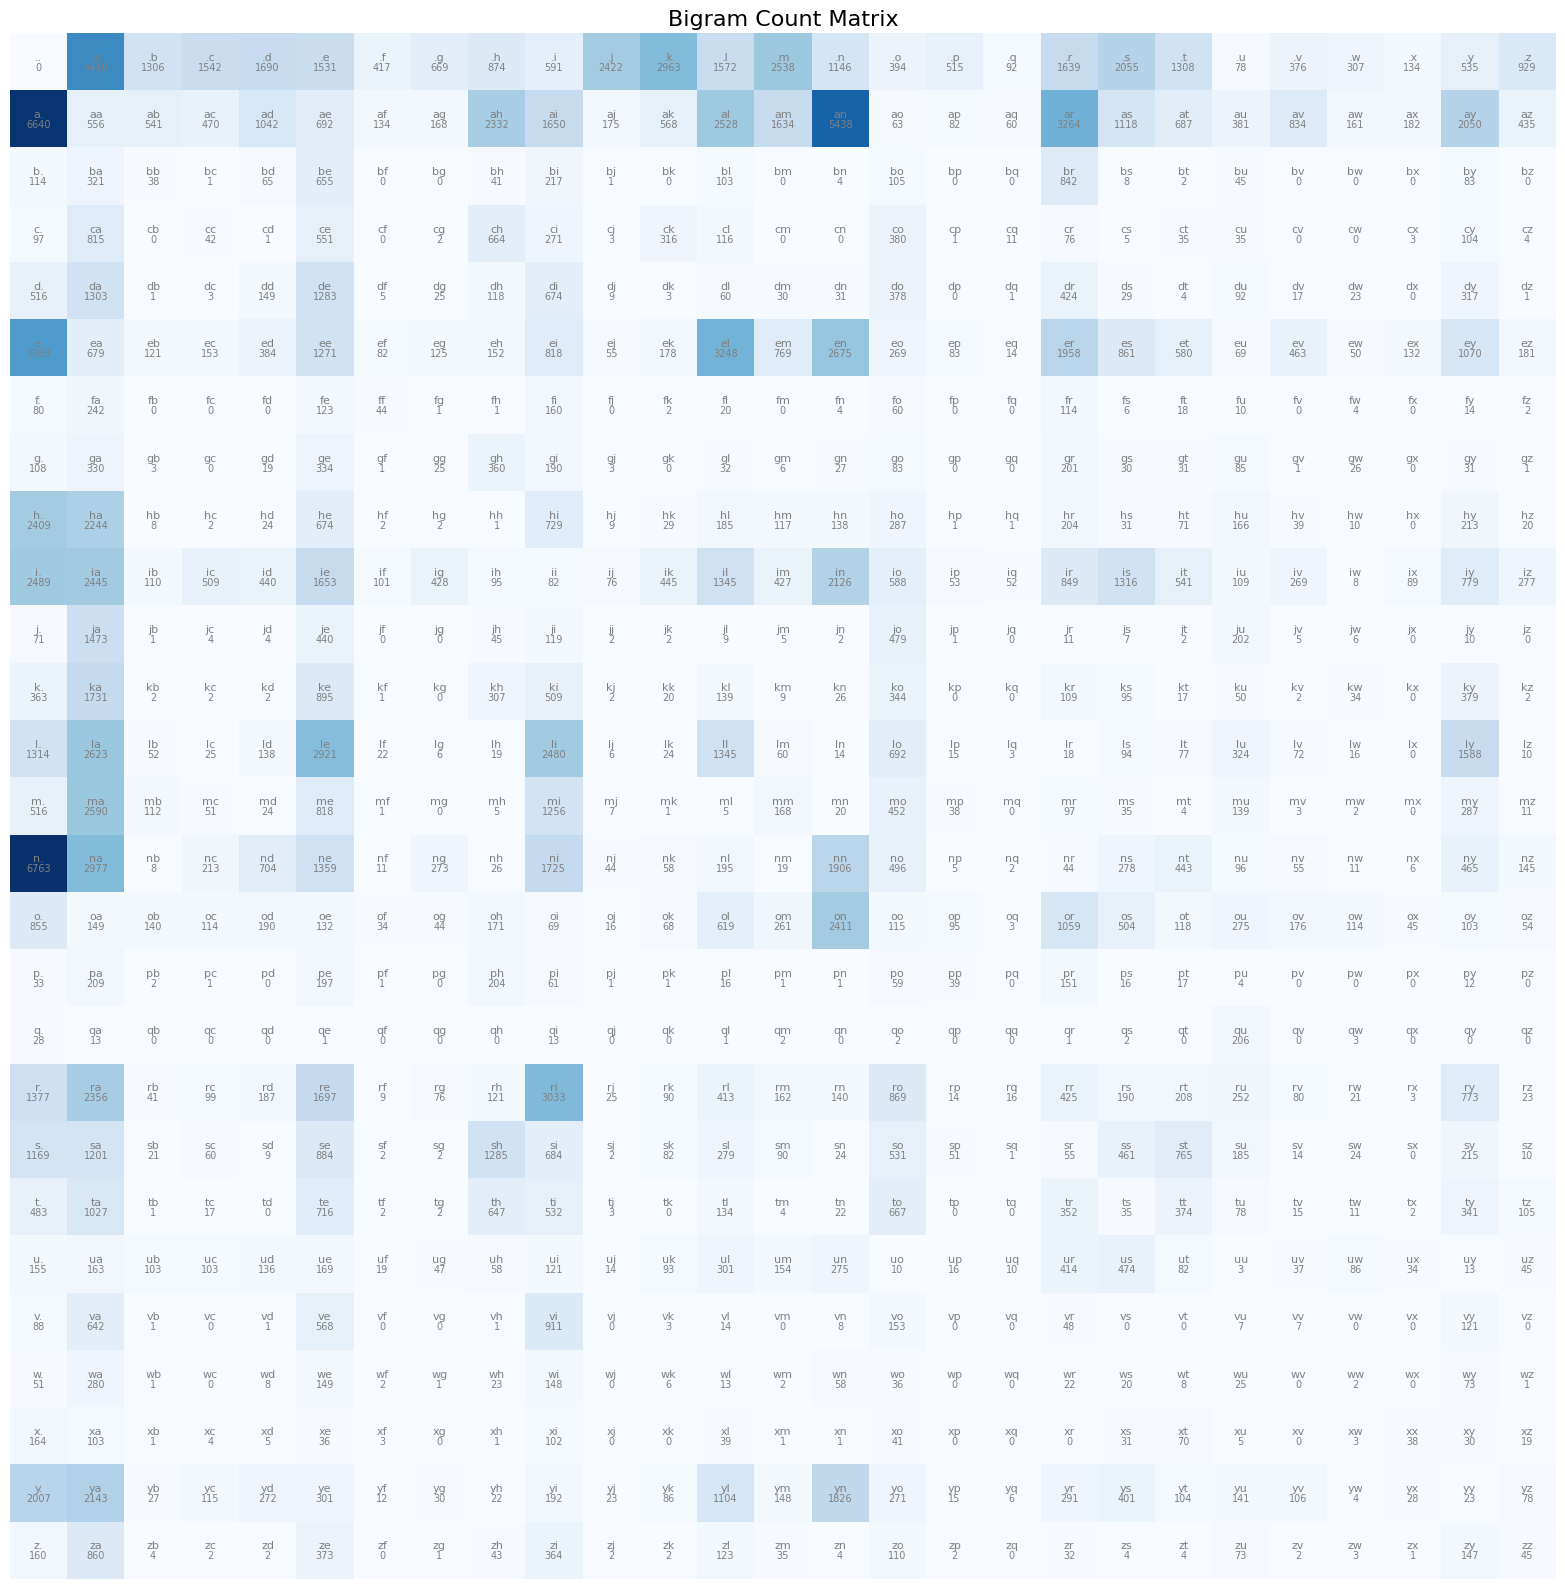

In [8]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(vocab_size):
    for j in range(vocab_size):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr,   ha='center', va='bottom', color='gray', fontsize=8)
        plt.text(j, i, N[i, j].item(), ha='center', va='top',    color='gray', fontsize=7)
plt.title('Bigram Count Matrix', fontsize=16)
plt.axis('off')
plt.tight_layout()

## 6  Statistical Model: Probability Matrix with Laplace Smoothing

To turn raw counts into probabilities we:
1. **Add 1 to every count** (Laplace / add-one smoothing) — this avoids zero probabilities for unseen bigrams, which would blow up the log-likelihood to −∞.
2. **Normalise each row** so all 27 values sum to 1, giving `P[i]` the probability distribution over the next character given character `i`.

In [9]:
P = (N + 1).float()                          # add-one smoothing
P /= P.sum(dim=1, keepdim=True)              # normalise each row → row-wise probability dist.

print('Row 0 (probabilities for next char after "."):')
print(P[0])
print(f'Row sum check: {P[0].sum().item():.4f}')   # should be 1.0

Row 0 (probabilities for next char after "."):
tensor([3.1192e-05, 1.3759e-01, 4.0767e-02, 4.8129e-02, 5.2745e-02, 4.7785e-02,
        1.3038e-02, 2.0898e-02, 2.7293e-02, 1.8465e-02, 7.5577e-02, 9.2452e-02,
        4.9064e-02, 7.9195e-02, 3.5777e-02, 1.2321e-02, 1.6095e-02, 2.9008e-03,
        5.1154e-02, 6.4130e-02, 4.0830e-02, 2.4641e-03, 1.1759e-02, 9.6070e-03,
        4.2109e-03, 1.6719e-02, 2.9008e-02])
Row sum check: 1.0000


## 7  Sample Names from the Statistical Model

To generate a name we do **autoregressive sampling**:
1. Start with the boundary token `.` (index 0).
2. Look up the probability distribution for the current character: `P[ix]`.
3. Sample the next character index using `torch.multinomial`.
4. Append the corresponding character to the output.
5. Repeat until the `.` end token is sampled.

In [10]:
g = torch.Generator().manual_seed(2147483647)   # fixed seed for reproducibility

print('Names sampled from the statistical bigram model:')
for _ in range(10):
    out = []
    ix = 0
    while True:
        p  = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:      # end token reached → word is complete
            break
    print(''.join(out[:-1]))   # strip trailing '.'

Names sampled from the statistical bigram model:
cexze
momasurailezitynn
konimittain
llayn
ka
da
staiyaubrtthrigotai
moliellavo
ke
teda


## 8  Evaluating the Statistical Model: Negative Log-Likelihood

We need a scalar **loss** to measure model quality.  We use the **average negative log-likelihood (NLL)**:

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N} \log P(c_{i+1} \mid c_i)$$

- A **lower** NLL means the model assigns higher probability to the actual next characters → it has learned the data better.
- Taking the log converts the product of probabilities into a sum (numerically stable).
- Negating flips the sign so we *minimise* rather than maximise.

In [11]:
log_likelihood = 0.0
n = 0

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        log_likelihood += torch.log(P[ix1, ix2]).item()
        n += 1

nll = -log_likelihood
avg_nll = nll / n

print(f'Total log-likelihood : {log_likelihood:.2f}')
print(f'Total NLL            : {nll:.2f}')
print(f'Average NLL (loss)   : {avg_nll:.4f}')

Total log-likelihood : -560001.88
Total NLL            : 560001.88
Average NLL (loss)   : 2.4546


### MLflow Logging — Statistical Model

In [12]:
# ── MLflow: Log Statistical Bigram Model Metrics ──────────────────────────────
with mlflow.start_run(run_name="bigram_statistical"):
    mlflow.log_param("model", "bigram_statistical")
    mlflow.log_param("smoothing", "laplace_add1")
    mlflow.log_param("vocab_size", vocab_size)

    # Recompute NLL for the statistical model
    ll_stat = 0.0
    n_stat  = 0
    for w in words:
        chs = ['.'] + list(w) + ['.']
        for ch1, ch2 in zip(chs, chs[1:]):
            ll_stat += torch.log(P[stoi[ch1], stoi[ch2]]).item()
            n_stat  += 1
    nll_stat_val = -ll_stat / n_stat

    mlflow.log_metric("val_nll", nll_stat_val)
    print(f"Statistical bigram NLL logged: {nll_stat_val:.4f}")

Statistical bigram NLL logged: 2.4546


## 9  Neural Network Approach: Dataset Preparation

We now replicate the statistical model using a **single linear layer** trained with gradient descent.  The key insight is:

> The rows of the weight matrix `W` after training should converge to (log) values proportional to the rows of the count matrix `N`.

**Dataset format:**  
- `xs` — integer tensor of *input* character indices (one per bigram)  
- `ys` — integer tensor of *target* character indices (the next character for each input)

We extract bigrams from the **full** dataset, so both tensors have one entry per consecutive character pair across all words.

In [13]:
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        xs.append(stoi[ch1])
        ys.append(stoi[ch2])

xs = torch.tensor(xs)   # shape: (num_bigrams,)
ys = torch.tensor(ys)   # shape: (num_bigrams,)

num = xs.nelement()
print(f'Total training bigrams: {num}')
print(f'xs[:5] = {xs[:5].tolist()}  →  {[itos[i] for i in xs[:5].tolist()]}')
print(f'ys[:5] = {ys[:5].tolist()}  →  {[itos[i] for i in ys[:5].tolist()]}')

Total training bigrams: 228146
xs[:5] = [0, 5, 13, 13, 1]  →  ['.', 'e', 'm', 'm', 'a']
ys[:5] = [5, 13, 13, 1, 0]  →  ['e', 'm', 'm', 'a', '.']


## 10  One-Hot Encoding

The neural network expects a **continuous vector** as input, not an integer index.  
We convert each integer index to a **one-hot vector** of length 27:  
all zeros except a single `1` at position `i`.

After encoding, `xenc` has shape `(num_bigrams, 27)` — one row per training example.

One-hot encoded input shape: torch.Size([228146, 27])
First example (input char index 0 = "."):


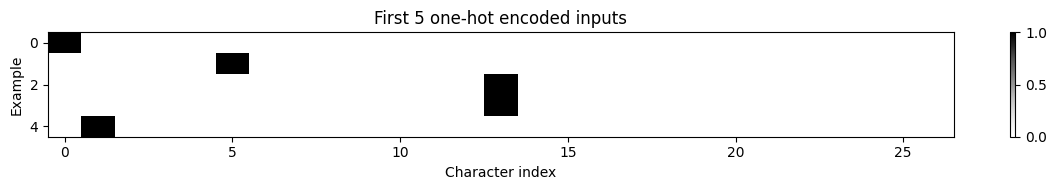

In [14]:
xenc = F.one_hot(xs, num_classes=vocab_size).float()   # (num_bigrams, 27)

print('One-hot encoded input shape:', xenc.shape)
print('First example (input char index 0 = "."):')
plt.figure(figsize=(12, 2))
plt.imshow(xenc[:5], cmap='Greys', aspect='auto')
plt.xlabel('Character index')
plt.ylabel('Example')
plt.title('First 5 one-hot encoded inputs')
plt.colorbar()
plt.tight_layout()

## 11  Initialise the Neural Network

Our model is a **single linear layer** — just one weight matrix `W` of shape `(27, 27)`.  
There is no bias and no activation function before the softmax.

- The matrix multiplication `xenc @ W` produces **logits** — unnormalised log-counts.  
- `W` is initialised with random normal values and tagged with `requires_grad=True` so PyTorch can compute gradients during backprop.

Conceptually this is equivalent to learning `log N[i]` (up to normalisation) for each row `i`.

In [15]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((vocab_size, vocab_size), generator=g, requires_grad=True)

print('Weight matrix shape:', W.shape)
print('(Each of the 27 rows is the learned log-count distribution for one input character.)')

Weight matrix shape: torch.Size([27, 27])
(Each of the 27 rows is the learned log-count distribution for one input character.)


## 12  Training Loop — Forward Pass, Backward Pass, and Weight Update

Each iteration of gradient descent performs three steps:

1. **Forward pass** — compute the loss:
   - `logits = xenc @ W` — dot product gives one logit vector per example
   - `counts = logits.exp()` — exponentiate to get positive "pseudo-counts"
   - `probs = counts / counts.sum(dim=1, keepdim=True)` — normalise → softmax probabilities
   - `loss` = mean NLL of the correct next characters + L2 regularisation on `W`

2. **Backward pass** — `loss.backward()` computes ∂loss/∂W automatically.

3. **Parameter update** — gradient descent: `W ← W - lr × ∂loss/∂W`.

> **L2 regularisation** (`0.01 * (W**2).mean()`) penalises large weights, acting as a smoothing prior that prevents the model from becoming overconfident on rare bigrams.

Step    0 | Loss: 3.7686
Step   20 | Loss: 2.5823
Step   40 | Loss: 2.5213
Step   60 | Loss: 2.5027
Step   80 | Loss: 2.4944
Step  100 | Loss: 2.4900
Step  120 | Loss: 2.4873
Step  140 | Loss: 2.4856
Step  160 | Loss: 2.4844
Step  180 | Loss: 2.4836
Step  199 | Loss: 2.4830


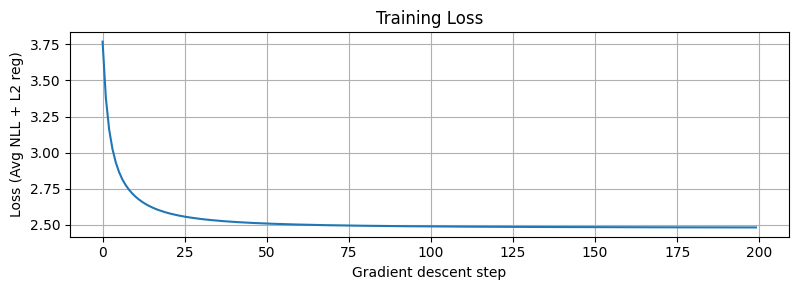

In [16]:
# Re-initialise weights so this cell can be run standalone
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((vocab_size, vocab_size), generator=g, requires_grad=True)

learning_rate = 50
num_steps     = 200
reg_strength  = 0.01     # L2 regularisation coefficient

losses = []
for step in range(num_steps):

    # ── Forward pass ──────────────────────────────────────────────────
    xenc   = F.one_hot(xs, num_classes=vocab_size).float()  # (N, 27)
    logits = xenc @ W                                        # (N, 27) — log-counts
    counts = logits.exp()                                    # (N, 27) — pseudo-counts
    probs  = counts / counts.sum(dim=1, keepdim=True)        # (N, 27) — softmax probs

    # NLL of correct next characters + L2 regularisation
    loss = -probs[torch.arange(num), ys].log().mean() + reg_strength * (W ** 2).mean()
    losses.append(loss.item())

    # ── Backward pass ─────────────────────────────────────────────────
    W.grad = None          # reset gradients (equivalent to optimizer.zero_grad())
    loss.backward()

    # ── Weight update (gradient descent) ──────────────────────────────
    W.data -= learning_rate * W.grad

    if step % 20 == 0 or step == num_steps - 1:
        print(f'Step {step:4d} | Loss: {loss.item():.4f}')

# Plot training curve
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel('Gradient descent step')
plt.ylabel('Loss (Avg NLL + L2 reg)')
plt.title('Training Loss')
plt.grid(True)
plt.tight_layout()

### MLflow Logging — Bigram Neural Network

The cell below re-runs the same training loop inside an `mlflow.start_run()` context, logging every hyperparameter, the step-wise loss, and the final weight matrix as an artifact.

In [17]:
# ── MLflow Run: Bigram Neural Network Training ────────────────────────────────
# Hyperparameters
hparams = {
    "model"        : "bigram_neural",
    "vocab_size"   : vocab_size,
    "learning_rate": learning_rate,
    "num_steps"    : num_steps,
    "reg_strength" : reg_strength,
}

with mlflow.start_run(run_name="bigram_neural_training"):
    # Log all hyperparameters
    mlflow.log_params(hparams)

    # Re-initialise weights for a clean tracked run
    g2 = torch.Generator().manual_seed(2147483647)
    W_tracked = torch.randn((vocab_size, vocab_size), generator=g2, requires_grad=True)

    tracked_losses = []
    for step in range(num_steps):
        xenc_t  = F.one_hot(xs, num_classes=vocab_size).float()
        logits_t = xenc_t @ W_tracked
        counts_t = logits_t.exp()
        probs_t  = counts_t / counts_t.sum(dim=1, keepdim=True)
        loss_t   = -probs_t[torch.arange(num), ys].log().mean() + reg_strength * (W_tracked**2).mean()

        W_tracked.grad = None
        loss_t.backward()
        W_tracked.data -= learning_rate * W_tracked.grad

        tracked_losses.append(loss_t.item())
        # Log loss every 20 steps to keep the run lean
        if step % 20 == 0 or step == num_steps - 1:
            mlflow.log_metric("train_loss", loss_t.item(), step=step)

    final_loss = tracked_losses[-1]
    mlflow.log_metric("final_train_loss", final_loss)

    # Log the weight matrix as an artifact (weights & biases equivalent)
    import tempfile, os
    with tempfile.TemporaryDirectory() as tmp:
        weight_path = os.path.join(tmp, "W_bigram.pt")
        import torch as _torch
        _torch.save(W_tracked.data, weight_path)
        mlflow.log_artifact(weight_path, artifact_path="model_weights")

    print(f"MLflow run complete. Final training loss: {final_loss:.4f}")
    print(f"Run logged under experiment: makemore-part1-bigram")
    print(f"View UI: mlflow ui  (in terminal, then open http://127.0.0.1:5000)")

MLflow run complete. Final training loss: 2.4830
Run logged under experiment: makemore-part1-bigram
View UI: mlflow ui  (in terminal, then open http://127.0.0.1:5000)


## 13  Sample Names from the Neural Network Model

Sampling from the neural network follows the same autoregressive procedure as before, but instead of looking up a row in the pre-computed probability matrix `P`, we:
1. One-hot encode the current character index.
2. Do a forward pass through `W` to get logits.
3. Apply softmax to obtain probabilities.
4. Sample the next character index from that distribution.

Because the neural net has been trained to minimise the same NLL objective, the generated names should look similar to those from the statistical model.

In [18]:
g = torch.Generator().manual_seed(2147483647)

print('Names sampled from the trained neural network:')
for _ in range(10):
    out = []
    ix  = 0
    while True:
        # One forward pass for a single character
        xenc   = F.one_hot(torch.tensor([ix]), num_classes=vocab_size).float()  # (1, 27)
        logits = xenc @ W                                                         # (1, 27)
        counts = logits.exp()
        p      = counts / counts.sum(dim=1, keepdim=True)                         # softmax

        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:   # end token → word complete
            break
    print(''.join(out[:-1]))

Names sampled from the trained neural network:
cexze
momasurailezityha
konimittain
llayn
ka
da
staiyaubrtthrigotai
moliellavo
ke
teda


## 14  Comparison: Statistical vs. Neural Network Model

Both approaches compute the same kind of probability distribution over the next character.  
Here we verify that their average NLLs are close — confirming the neural network has converged to approximately the same solution as the statistical model.

In [19]:
# ── Statistical model NLL (from Section 8) ────────────────────────────────
log_lik_stat = 0.0
n_stat       = 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        log_lik_stat += torch.log(P[stoi[ch1], stoi[ch2]]).item()
        n_stat += 1
nll_stat = -log_lik_stat / n_stat

# ── Neural network model NLL ───────────────────────────────────────────────
with torch.no_grad():
    xenc_all = F.one_hot(xs, num_classes=vocab_size).float()
    logits   = xenc_all @ W
    counts   = logits.exp()
    probs    = counts / counts.sum(dim=1, keepdim=True)
    nll_nn   = -probs[torch.arange(num), ys].log().mean().item()

print(f'Statistical model  — Average NLL: {nll_stat:.4f}')
print(f'Neural network     — Average NLL: {nll_nn:.4f}')
print()
print('The two values converge because the neural network learns the same')
print('log-count statistics that the count matrix captures directly.')

Statistical model  — Average NLL: 2.4546
Neural network     — Average NLL: 2.4653

The two values converge because the neural network learns the same
log-count statistics that the count matrix captures directly.


In [20]:
# ── Install MLflow if not already installed ──
!pip install mlflow -q

# ── View all logged runs ──
import mlflow
mlflow.set_tracking_uri("mlruns")
client = mlflow.tracking.MlflowClient()

for exp_name in ["makemore-part1-bigram", "makemore-part2-mlp"]:
    experiment = client.get_experiment_by_name(exp_name)
    if experiment is None:
        print(f"No experiment found for: {exp_name}")
        continue
    runs = client.search_runs(experiment.experiment_id)
    print(f"\nExperiment: {experiment.name}  |  Runs: {len(runs)}")
    for run in runs:
        print(f"  Run: {run.info.run_name}")
        for k, v in run.data.params.items():
            print(f"    Param  {k}: {v}")
        for k, v in run.data.metrics.items():
            print(f"    Metric {k}: {v:.4f}")
        print()


Experiment: makemore-part1-bigram  |  Runs: 2
  Run: bigram_neural_training
    Param  num_steps: 200
    Param  reg_strength: 0.01
    Param  model: bigram_neural
    Param  vocab_size: 27
    Param  learning_rate: 50
    Metric train_loss: 2.4830
    Metric final_train_loss: 2.4830

  Run: bigram_statistical
    Param  model: bigram_statistical
    Param  vocab_size: 27
    Param  smoothing: laplace_add1
    Metric val_nll: 2.4546

No experiment found for: makemore-part2-mlp
